<a href="https://colab.research.google.com/github/dyytnn/tannguyen.github.io/blob/main/LayoutLMv2/FUNSD/Fine_tuning_LayoutLMv2ForTokenClassification_on_FUNSD_using_HuggingFace_Trainer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook, we are going to fine-tune `LayoutLMv2ForTokenClassification` on the [FUNSD](https://guillaumejaume.github.io/FUNSD/) dataset. The goal for the model is to label words appearing in scanned documents appropriately. This task is treated as a NER problem (sequence labeling). However, compared to BERT, LayoutLMv2 also incorporates visual and layout information about the tokens when encoding them into vectors. This makes the LayoutLMv2 model very powerful for document understanding tasks.

LayoutLMv2 is itself an upgrade of LayoutLM. The main novelty of LayoutLMv2 is that it also pre-trains visual embeddings, whereas the original LayoutLM only adds visual embeddings during fine-tuning.

* Paper: https://arxiv.org/abs/2012.14740
* Original repo: https://github.com/microsoft/unilm/tree/master/layoutlmv2

## Install dependencies

First, we install the required libraries:
* Transformers (for the LayoutLMv2 model)
* Datasets (for data preprocessing)
* Seqeval (for metrics)
* Detectron2 (which LayoutLMv2 requires for its visual backbone).



In [ ]:
!pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 895 kB 8.4 MB/s 
     |████████████████████████████████| 50 kB 9.2 MB/s 
     |████████████████████████████████| 636 kB 62.0 MB/s 
     |████████████████████████████████| 3.3 MB 48.4 MB/s 


In [ ]:
!pip install -q datasets seqeval

     |████████████████████████████████| 264 kB 6.6 MB/s 
     |████████████████████████████████| 43 kB 2.4 MB/s 
     |████████████████████████████████| 243 kB 53.5 MB/s 
     |████████████████████████████████| 118 kB 74.5 MB/s 


In [64]:
# !pip install -q pyyaml==5.1
# workaround: install old version of pytorch since detectron2 hasn't released packages for pytorch 1.9 (issue: https://github.com/facebookresearch/detectron2/issues/3158)
# !pip install -q torch==1.8.0+cu101 torchvision==0.9.0+cu101 -f https://download.pytorch.org/whl/torch_stable.html

# install detectron2 that matches pytorch 1.8
# See https://detectron2.readthedocs.io/tutorials/install.html for instructions
# !pip install -q detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu101/torch1.8/index.html
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-r2iyp1_9
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-r2iyp1_9
  Resolved https://github.com/facebookresearch/detectron2.git to commit 18f69583391e5040043ca4f4bebd2c60f0ebfde0
  Preparing metadata (setup.py) ... done
  Using cached yacs-0.1.8-py3-none-any.whl.metadata (639 bytes)
  Using cached fvcore-0.1.5.post20221221.tar.gz (50 kB)
  Preparing metadata (setup.py) ... done
  Using cached iopath-0.1.9-py3-none-any.whl.metadata (370 bytes)
  Using cached hydra_core-1.3.2-py3-none-any.whl.metadata (5.5 kB)
  Using cached black-25.1.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (81 kB)
  Using cached portalocker-3.2.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached mypy_extensions-1.1.0-py3-none-any.whl.metadata (1.1 kB)
  Using cached pathspec-0.12.1-py3-none-any.whl.metadata (21

To be able to share your model with the community on the HuggingFace hub, there are a few more steps to follow.

First you have to store your authentication token from the Hugging Face website (sign up [here](https://huggingface.co/welcome) if you haven't already!) then uncomment the following cell and input your username and password (this only works on Colab, in a regular notebook, you need to do this in a terminal):

In [2]:
!huggingface-cli login

⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) Y
Token is valid (permission: fineGrained).
The token `newme` has been saved to /root/.cache/huggingface/stored_tokens
Cannot authenticate through git-credent

Then you need to install Git-LFS (which is used by the hub) and setup Git if you haven't already. Uncomment the following instructions and adapt with your name and email:

In [3]:
!apt install git-lfs
!git config --global user.email "example@gmail.com"
!git config --global user.name "your name"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


## Prepare the data

Let's load the FUNSD dataset from the HuggingFace hub.

In [4]:
from datasets import load_dataset

datasets = load_dataset("nielsr/funsd")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/755 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/12.3M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/4.38M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/149 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50 [00:00<?, ? examples/s]

As we can see, it contains a training and test split. Each example consists of an id, tokens, bounding boxes, NER tags (in IOB format) and a document image. Note: tokens might be a bit misleading here, because these are still words. We need to convert them to actual tokens (word pieces) using the tokenizer.

In [5]:
datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'words', 'bboxes', 'ner_tags', 'image'],
        num_rows: 149
    })
    test: Dataset({
        features: ['id', 'words', 'bboxes', 'ner_tags', 'image'],
        num_rows: 50
    })
})

In [6]:
datasets['train'].features

{'id': Value('string'),
 'words': List(Value('string')),
 'bboxes': List(List(Value('int64'))),
 'ner_tags': List(ClassLabel(names=['O', 'B-HEADER', 'I-HEADER', 'B-QUESTION', 'I-QUESTION', 'B-ANSWER', 'I-ANSWER'])),
 'image': Image(mode=None, decode=True)}

## Preprocess data

First, let's store the labels in a list, and create dictionaries that let us map from labels to integer indices and vice versa. The latter will be useful when evaluating the model.

In [8]:
labels = datasets['train'].features['ner_tags'].feature.names
print(labels)

['O', 'B-HEADER', 'I-HEADER', 'B-QUESTION', 'I-QUESTION', 'B-ANSWER', 'I-ANSWER']


In [9]:
id2label = {v: k for v, k in enumerate(labels)}
label2id = {k: v for v, k in enumerate(labels)}
label2id

{'O': 0,
 'B-HEADER': 1,
 'I-HEADER': 2,
 'B-QUESTION': 3,
 'I-QUESTION': 4,
 'B-ANSWER': 5,
 'I-ANSWER': 6}

Next, let's use `LayoutLMv2Processor` to prepare the data for the model.

In [48]:
def _to_pil_rgb(x):
    # x can be PIL.Image, bytes, or numpy array
    if isinstance(x, Image.Image):
        im = x
    elif isinstance(x, (bytes, bytearray)):
        im = Image.open(BytesIO(x))
    elif isinstance(x, np.ndarray):
        arr = x
        if arr.ndim == 2:  # (H, W) grayscale
            im = Image.fromarray(arr.astype(np.uint8), mode='L')
        elif arr.ndim == 3:
            # handle channel-first (C,H,W) or channel-last (H,W,C)
            if arr.shape[0] in (1, 3, 4) and arr.shape[0] <= 4:  # likely (C,H,W)
                arr = np.transpose(arr, (1, 2, 0))
            im = Image.fromarray(arr.astype(np.uint8))
        else:
            raise ValueError(f"Unsupported image array shape: {getattr(arr, 'shape', None)}")
    else:
        raise TypeError(f"Unsupported image type: {type(x)}")

    if im.mode != "RGB":
        im = im.convert("RGB")
    return im

In [54]:
from io import BytesIO
import numpy as np
from PIL import Image

def _to_pil_rgb(x):
    if isinstance(x, Image.Image):
        im = x
    elif isinstance(x, (bytes, bytearray)):
        im = Image.open(BytesIO(x))
    elif isinstance(x, np.ndarray):
        arr = x
        if arr.ndim == 2:
            im = Image.fromarray(arr.astype(np.uint8), mode='L')
        elif arr.ndim == 3:
            if arr.shape[0] in (1, 3, 4):  # likely (C,H,W)
                arr = np.transpose(arr, (1, 2, 0))
            im = Image.fromarray(arr.astype(np.uint8))
        else:
            raise ValueError(f"Unsupported array shape: {getattr(arr, 'shape', None)}")
    else:
        raise TypeError(f"Unsupported type: {type(x)}")
    return im.convert("RGB")

features = Features({
    "input_ids": Sequence(Value("int64")),
    "attention_mask": Sequence(Value("int64")),
    "token_type_ids": Sequence(Value("int64")),
    "bbox": Array2D(shape=(512, 4), dtype="int64"),
    "labels": Sequence(ClassLabel(names=labels)),
    "pixel_values": Array3D(shape=(3, 224, 224), dtype="float32"),
    # If your processor returns pixel_mask, uncomment next line and keep it in the return:
    # "pixel_mask": Array2D(shape=(224, 224), dtype="float32"),
})

def preprocess_data(examples):
    images = [_to_pil_rgb(x) for x in examples["image"]]
    words = examples["words"]
    boxes = examples["bboxes"]
    word_labels = examples["ner_tags"]

    encoded = processor(
        images=images,
        text=words,
        boxes=boxes,
        word_labels=word_labels,
        padding="max_length",
        truncation=True,
        return_tensors=None,
    )

    # Keep ONLY the columns declared in `features`
    keep = set(features.keys())
    encoded = {k: v for k, v in encoded.items() if k in keep}
    return encoded

train_dataset = datasets["train"].map(
    preprocess_data,
    batched=True,
    remove_columns=datasets["train"].column_names,  # ok to remove all originals
    features=features,
)

test_dataset = datasets["test"].map(
    preprocess_data,
    batched=True,
    remove_columns=datasets["test"].column_names,
    features=features,
)


Map:   0%|          | 0/149 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [53]:
datasets["train"]['image']

Column([<PIL.PngImagePlugin.PngImageFile image mode=L size=762x1000 at 0x7EEC01B0F3D0>, <PIL.PngImagePlugin.PngImageFile image mode=L size=762x1000 at 0x7EEC01DF3610>, <PIL.PngImagePlugin.PngImageFile image mode=L size=762x1000 at 0x7EEC014CFB50>, <PIL.PngImagePlugin.PngImageFile image mode=L size=762x1000 at 0x7EEC01933A10>, <PIL.PngImagePlugin.PngImageFile image mode=L size=771x1000 at 0x7EEC01932250>])

In [39]:
import pandas as pd

df = pd.DataFrame(datasets['train'])

In [23]:
np.array(df["image"][2]).shape

(1000, 762)

In [17]:
import numpy as np

# Convert all bbox coordinates into a single numpy array
all_bboxes = np.array([coord for sample in df["bboxes"] for coord in sample])

# Find min and max over all coordinates
min_x = all_bboxes[:, 0].min()
min_y = all_bboxes[:, 1].min()
max_x = all_bboxes[:, 2].max()
max_y = all_bboxes[:, 3].max()

print(f"Min X: {min_x}, Min Y: {min_y}")
print(f"Max X: {max_x}, Max Y: {max_y}")


Min X: 0, Min Y: 0
Max X: 992, Max Y: 992


In [27]:
print(df.loc[0, "bboxes"])
print(df.loc[0, "image"])

[[383, 91, 493, 175], [287, 316, 295, 327], [124, 355, 221, 370], [632, 268, 679, 282], [670, 309, 748, 323], [604, 605, 633, 619], [715, 603, 738, 617], [688, 904, 841, 926], [337, 203, 366, 214], [374, 203, 438, 216], [447, 201, 548, 211], [335, 215, 425, 229], [434, 214, 507, 228], [518, 215, 555, 228], [116, 274, 154, 289], [153, 274, 166, 288], [167, 274, 213, 289], [221, 272, 257, 287], [257, 274, 267, 288], [282, 272, 301, 287], [311, 272, 376, 286], [384, 272, 402, 286], [412, 274, 476, 285], [485, 272, 503, 285], [511, 271, 591, 282], [712, 265, 734, 279], [734, 264, 754, 279], [754, 264, 774, 279], [551, 310, 580, 323], [587, 310, 644, 323], [309, 313, 329, 327], [335, 313, 358, 326], [364, 313, 429, 327], [119, 316, 211, 330], [213, 318, 221, 331], [221, 317, 286, 327], [249, 355, 351, 366], [359, 353, 397, 366], [405, 352, 492, 365], [500, 351, 570, 365], [581, 352, 601, 363], [608, 348, 682, 362], [691, 346, 779, 361], [249, 369, 314, 383], [324, 367, 395, 380], [417, 365,

In [40]:
from PIL import ImageDraw, ImageFont

def annotate_bboxes(img, bboxes, color=(255, 0, 0), width=2, show_index=True):
    """
    img: PIL.Image (any mode). Will be converted to RGB for colored outlines.
    bboxes: iterable of [x1, y1, x2, y2]
    """
    if img.mode != "RGB":
        img = img.convert("RGB")
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.load_default()
    except:
        font = None

    W, H = img.size
    for i, (x1, y1, x2, y2) in enumerate(bboxes):
        # clip to image bounds
        x1 = max(0, min(W-1, x1))
        y1 = max(0, min(H-1, y1))
        x2 = max(0, min(W-1, x2))
        y2 = max(0, min(H-1, y2))

        draw.rectangle([x1, y1, x2, y2], outline=color, width=width)

        if show_index:
            label = str(i)
            # Get text size safely for all Pillow versions
            if hasattr(draw, "textbbox"):
                tw, th = draw.textbbox((0, 0), label, font=font)[2:]
            else:
                tw, th = font.getsize(label)

            draw.rectangle([x1, y1 - th, x1 + tw + 2, y1], fill=color)
            draw.text((x1 + 1, y1 - th), label, fill=(255,255,255), font=font)

    return img


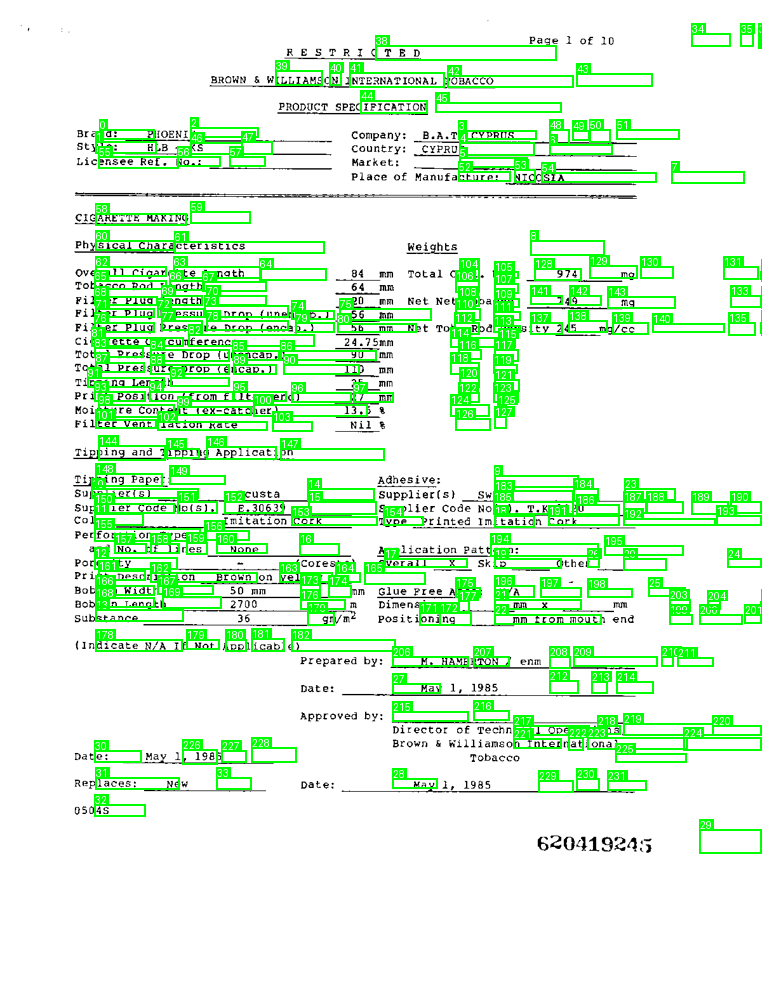

In [43]:
bboxes = df.loc[1, "bboxes"]          # list of [x1,y1,x2,y2]
img = df.loc[1, "image"]              # PIL image (mode=L, size=762x1000)

out = annotate_bboxes(img.copy(), bboxes, color=(0, 255, 0), width=2)
out


Let's verify the first example:

In [55]:
processor.tokenizer.decode(train_dataset['input_ids'][0])

'[CLS] r & d : suggestion : date : licensee yes no 597005708 r & d quality improvement suggestion / solution form name / phone ext. : m. hamann p. harper, p. martinez 9 / 3 / 92 r & d group : j. s. wigand supervisor / manager discontinue coal retention analyses on licensee submitted product samples ( note : coal retention testing is not performed by most licensees. other b & w physical measurements as ends stability and inspection for soft spots in ciparettes are thought to be sufficient measures to assure cigarette physical integrity. the proposed action will increase laboratory productivity. ) suggested solutions ( s ) : delete coal retention from the list of standard analyses performed on licensee submitted product samples. special requests for coal retention testing could still be submitted on an exception basis. have you contacted your manager / supervisor? manager comments : manager, please contact suggester and forward comments to the quality council. qip. wp [SEP] [PAD] [PAD] [

In [ ]:
print(train_dataset['labels'][0])

[-100, 0, -100, -100, 3, 3, -100, 3, -100, 5, -100, 3, 3, 0, -100, -100, -100, -100, -100, 1, -100, -100, 2, 2, 2, -100, 2, 2, 3, 4, 4, 4, -100, -100, 4, 5, -100, 6, -100, 6, -100, 6, -100, 6, -100, 6, 5, -100, 6, -100, 6, 3, -100, -100, 4, -100, 5, -100, 6, -100, 6, -100, 3, 4, 4, 5, -100, -100, -100, 6, 6, 6, 6, 6, -100, 6, 6, 6, 6, -100, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, -100, -100, 6, 6, -100, -100, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, -100, -100, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, -100, 6, 6, 6, 6, 6, 6, 6, 6, 6, 3, 4, 4, -100, -100, 4, 5, -100, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, -100, 6, 6, 6, -100, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, -100, 1, 2, 2, 2, 2, -100, 2, -100, 3, 4, -100, 5, -100, 6, 6, 6, -100, 6, 6, 5, 6, 6, 6, 6, -100, 0, -100, 0, 0, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 

In [56]:
print(train_dataset['labels'][0])

[-100, 0, -100, -100, 3, 3, -100, 3, -100, 5, -100, 3, 3, 0, -100, -100, -100, -100, -100, 1, -100, -100, 2, 2, 2, -100, 2, 2, 3, 4, 4, 4, -100, -100, 4, 5, -100, 6, -100, 6, -100, 6, -100, 6, -100, 6, 5, -100, 6, -100, 6, 3, -100, -100, 4, -100, 5, -100, 6, -100, 6, -100, 3, 4, 4, 5, -100, -100, -100, 6, 6, 6, 6, 6, -100, 6, 6, 6, 6, -100, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, -100, -100, 6, 6, -100, -100, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, -100, -100, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, -100, 6, 6, 6, 6, 6, 6, 6, 6, 6, 3, 4, 4, -100, -100, 4, 5, -100, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, -100, 6, 6, 6, -100, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, -100, 1, 2, 2, 2, 2, -100, 2, -100, 3, 4, -100, 5, -100, 6, 6, 6, -100, 6, 6, 5, 6, 6, 6, 6, -100, 0, -100, 0, 0, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 

Finally, let's set the format to PyTorch.

In [57]:
train_dataset.set_format(type="torch")
test_dataset.set_format(type="torch")

In [58]:
train_dataset.features.keys()

dict_keys(['input_ids', 'attention_mask', 'token_type_ids', 'bbox', 'labels', 'pixel_values'])

Next, we create corresponding dataloaders.

In [59]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=2)

In [65]:
data = next(iter(train_dataloader))

In [67]:
data.keys()

dict_keys(['input_ids', 'attention_mask', 'token_type_ids', 'bbox', 'labels', 'pixel_values'])

In [68]:
data['token_type_ids']

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])

Let's verify a batch:

In [60]:
batch = next(iter(train_dataloader))

for k,v in batch.items():
  print(k, v.shape)

input_ids torch.Size([4, 512])
attention_mask torch.Size([4, 512])
token_type_ids torch.Size([4, 512])
bbox torch.Size([4, 512, 4])
labels torch.Size([4, 512])
pixel_values torch.Size([4, 3, 224, 224])


## Train the model

Here we train the model using HuggingFace's Trainer. We need to overwrite a few methods, namely those that return the PyTorch dataloaders, as we defined custom dataloaders above.

We can initialize a `Trainer` by passing our model as well as `TrainingArguments`. See the [docs](https://huggingface.co/transformers/main_classes/trainer.html) for all possible arguments..

In [62]:
from transformers import LayoutLMv2ForTokenClassification, TrainingArguments, Trainer
# from datasets import load_metric
import numpy as np

model = LayoutLMv2ForTokenClassification.from_pretrained('microsoft/layoutlmv2-base-uncased',
                                                                      num_labels=len(label2id))

# Set id2label and label2id
model.config.id2label = id2label
model.config.label2id = label2id

# # Metrics
# metric = load_metric("seqeval")
# return_entity_level_metrics = True

# def compute_metrics(p):
#     predictions, labels = p
#     predictions = np.argmax(predictions, axis=2)

#     # Remove ignored index (special tokens)
#     true_predictions = [
#         [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
#         for prediction, label in zip(predictions, labels)
#     ]
#     true_labels = [
#         [id2label[l] for (p, l) in zip(prediction, label) if l != -100]
#         for prediction, label in zip(predictions, labels)
#     ]

#     results = metric.compute(predictions=true_predictions, references=true_labels)
#     if return_entity_level_metrics:
#         # Unpack nested dictionaries
#         final_results = {}
#         for key, value in results.items():
#             if isinstance(value, dict):
#                 for n, v in value.items():
#                     final_results[f"{key}_{n}"] = v
#             else:
#                 final_results[key] = value
#         return final_results
#     else:
#         return {
#             "precision": results["overall_precision"],
#             "recall": results["overall_recall"],
#             "f1": results["overall_f1"],
#             "accuracy": results["overall_accuracy"],
#         }

class FunsdTrainer(Trainer):
    def get_train_dataloader(self):
      return train_dataloader

    def get_test_dataloader(self, test_dataset):
      return test_dataloader

args = TrainingArguments(
    output_dir="layoutlmv2-finetuned-funsd-v2", # name of directory to store the checkpoints
    max_steps=1000, # we train for a maximum of 1,000 batches
    warmup_ratio=0.1, # we warmup a bit
    fp16=True, # we use mixed precision (less memory consumption)
    push_to_hub=True, # after training, we'd like to push our model to the hub
    push_to_hub_model_id=f"layoutlmv2-finetuned-funsd-test", # this is the name we'll use for our model on the hub
)

# Initialize our Trainer
trainer = FunsdTrainer(
    model=model,
    args=args,
    # compute_metrics=compute_metrics,
)

pytorch_model.bin:   0%|          | 0.00/802M [00:00<?, ?B/s]

ImportError: 
LayoutLMv2Model requires the detectron2 library but it was not found in your environment. Check out the instructions on the
installation page: https://github.com/facebookresearch/detectron2/blob/master/INSTALL.md and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.


Let's train the model! By default, the Trainer saves checkpoints every 500 steps.

In [ ]:
trainer.train()

***** Running training *****
  Num examples = 8000
  Num Epochs = 9223372036854775807
  Instantaneous batch size per device = 8
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 1
  Total optimization steps = 1000


Step,Training Loss
500,0.798200
1000,0.218400


Saving model checkpoint to layoutlmv2-finetuned-funsd-v2/checkpoint-500
Configuration saved in layoutlmv2-finetuned-funsd-v2/checkpoint-500/config.json
Model weights saved in layoutlmv2-finetuned-funsd-v2/checkpoint-500/pytorch_model.bin
Saving model checkpoint to layoutlmv2-finetuned-funsd-v2/checkpoint-1000
Configuration saved in layoutlmv2-finetuned-funsd-v2/checkpoint-1000/config.json
Model weights saved in layoutlmv2-finetuned-funsd-v2/checkpoint-1000/pytorch_model.bin


Training completed. Do not forget to share your model on huggingface.co/models =)




TrainOutput(global_step=1000, training_loss=0.5082762908935546, metrics={'train_runtime': 628.7041, 'train_samples_per_second': 12.725, 'train_steps_per_second': 1.591, 'total_flos': 2117231568021504.0, 'train_loss': 0.5082762908935546, 'epoch': 26.01})

To compute metrics on the test set, we can run `trainer.predict()`. We get predictions, labels, and metrics back.

In [ ]:
predictions, labels, metrics = trainer.predict(test_dataset)

***** Running Prediction *****
  Num examples = 50
  Batch size = 2


In [ ]:
print(metrics)

{'test_loss': 0.6071677207946777, 'test_ANSWER_precision': 0.7882219705549264, 'test_ANSWER_recall': 0.8603213844252163, 'test_ANSWER_f1': 0.822695035460993, 'test_ANSWER_number': 809, 'test_HEADER_precision': 0.6017699115044248, 'test_HEADER_recall': 0.5714285714285714, 'test_HEADER_f1': 0.5862068965517241, 'test_HEADER_number': 119, 'test_QUESTION_precision': 0.8778846153846154, 'test_QUESTION_recall': 0.8572769953051643, 'test_QUESTION_f1': 0.867458432304038, 'test_QUESTION_number': 1065, 'test_overall_precision': 0.8236738703339882, 'test_overall_recall': 0.8414450577019569, 'test_overall_f1': 0.8324646314221892, 'test_overall_accuracy': 0.831893532570628, 'test_runtime': 4.3836, 'test_samples_per_second': 11.406, 'test_steps_per_second': 1.597}


The numbers I got where:

* run 1: `'test_overall_precision': 0.8190854870775348, 'test_overall_recall': 0.8268941294530858, 'test_overall_f1': 0.8229712858926342`
* run 2: `'test_overall_precision': 0.8236738703339882, 'test_overall_recall': 0.8414450577019569, 'test_overall_f1': 0.8324646314221892`

## Share model on the hub

Finally, we can easily push our model to the hub as follows:

In [ ]:
trainer.push_to_hub()